# BDC Yield 🏦
### A "10% income" fund that lost *more* than the stock market in COVID — does the BDC yield survive credit cycles?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survives credit cycles?: Busted](https://img.shields.io/badge/Survives_credit_cycles%3F-Busted-8b949e?style=flat-square)

Business development companies (and the ETF that holds a basket of them, **BIZD**) are sold on one number: a **~10% yield**. They lend to private mid-market companies, the pitch goes — senior secured loans, high income, bond-like steadiness. We line BIZD up next to a stock fund and a bond fund and ask the only question that matters: when credit cracks, does that 10% act like the bond income it's sold as — or like the *levered equity* it really is?

> 📓 **This is the plain-language layer.** The betas, the HAC *t* and the bootstrap are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Educational, reproducible research — every chart below is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (bdc_yield/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from bdc_yield import data, strategy

AS_OF = "2026-05-31"
QUOTED_YIELD = 0.10   # BIZD's headline distribution rate, ~10%
# Try the REAL total-return tapes; fall back to the offline synthetic control if the
# network is blocked. Every cell prints which TAPE it is showing.
try:
    prices = data.load_real(("BIZD", "SPY", "IEF")).loc[:AS_OF]
    cols = {"BIZD": "BIZD", "SPY": "SPY", "BND": "IEF"}   # bond proxy label
    TAPE = "REAL"
except Exception as e:
    print("network/cache miss -> SYNTHETIC control tape:", type(e).__name__)
    prices, _truth = data.synthetic_three_asset(bdc_beta=1.15, seed=342)
    cols = {"BIZD": "BIZD", "SPY": "SPY", "BND": "BND"}
    TAPE = "SYNTHETIC"

BIZD, SPY, BND = cols["BIZD"], cols["SPY"], cols["BND"]
rets = strategy.to_returns(prices)
BANNER = ("REAL total-return tape (BIZD/SPY/IEF, 2013-2026)" if TAPE == "REAL"
          else "SYNTHETIC control tape (bdc_beta=1.15) -- NOT market data")
print(f"[{TAPE}] {BANNER}")
print(f"panel: {len(prices):,} rows  {prices.index[0].date()} -> {prices.index[-1].date()}  fingerprint={data.fingerprint(prices)}")
for c in (BIZD, SPY, BND):
    s = strategy.stats(rets[c])
    print(f"  {c}: CAGR {s['cagr']*100:6.2f}%  vol {s['vol']*100:5.1f}%  Sharpe {s['sharpe']:.3f}  maxDD {s['max_dd']*100:6.1f}%")


[REAL] REAL total-return tape (BIZD/SPY/IEF, 2013-2026)
panel: 3,344 rows  2013-02-12 -> 2026-05-29  fingerprint=1773bea09c5d
  BIZD: CAGR   6.21%  vol  20.1%  Sharpe 0.401  maxDD  -55.4%
  SPY: CAGR  14.81%  vol  16.9%  Sharpe 0.903  maxDD  -33.7%
  IEF: CAGR   1.32%  vol   6.5%  Sharpe 0.235  maxDD  -23.9%


## The answer first 🎯

| Question | Answer |
|---|---|
| Does the ~10% yield actually pay? | Only **~6.21%/yr** of it became real total return — **38%** of the headline never showed up as wealth. |
| Is the ride bond-like? | **No** — vol **20.1%** (*above* the S&P 500's **16.9%**), and its worst fall was **-55.4%**, far deeper than stocks. |
| Does it survive a credit crash? | **No** — BIZD fell in **6 of 6** equity crashes; in COVID it lost **-55.0%** while bonds *gained* **+6.4%**. |

> *Headline numbers are the **real** 2013–2026 tape (`docs/results.md`, fingerprint `1773bea09c5d`). If the executed cells below show a SYNTHETIC banner, the live data was blocked and the harness fell back to the offline control — the prose numbers still refer to the real run.*

## 1 · The claim

*"BDCs pay a ~10% yield — high income with bond-like steadiness, because they hold **senior secured loans** to private companies. You collect a double-digit distribution with the safety of senior debt."* It's how the funds are marketed and how income investors file them: in the *income* bucket, a fat-yield complement to bonds.

## 2 · So what?

If the pitch is true, BIZD is a retirement-income dream — five times a Treasury's yield with senior-loan safety. If it's false, income investors are holding **levered private-credit equity** in the part of the portfolio they believe is steady — and they find out at the worst possible moment, when the same recession that cuts the credit also cuts the price. The label decides whether this is income or risk.

## 3 · How would we even know?

We compare BIZD (total return — distributions folded back in) to a **stock** fund (SPY) and a **bond** fund (IEF, 7-10y Treasuries) from 2013 — so BIZD's first real test was the 2020 COVID crash. First, the honest question: how much of the ~10% headline actually *arrived* as total return? Then the decisive one: every time stocks fell more than 10%, **did BIZD rise (like a bond) or fall (like a stock)?**

## 4 · The teardown — let's actually look

First, the three equity curves and their drawdowns. Watch what the '10% income' line does in 2020.

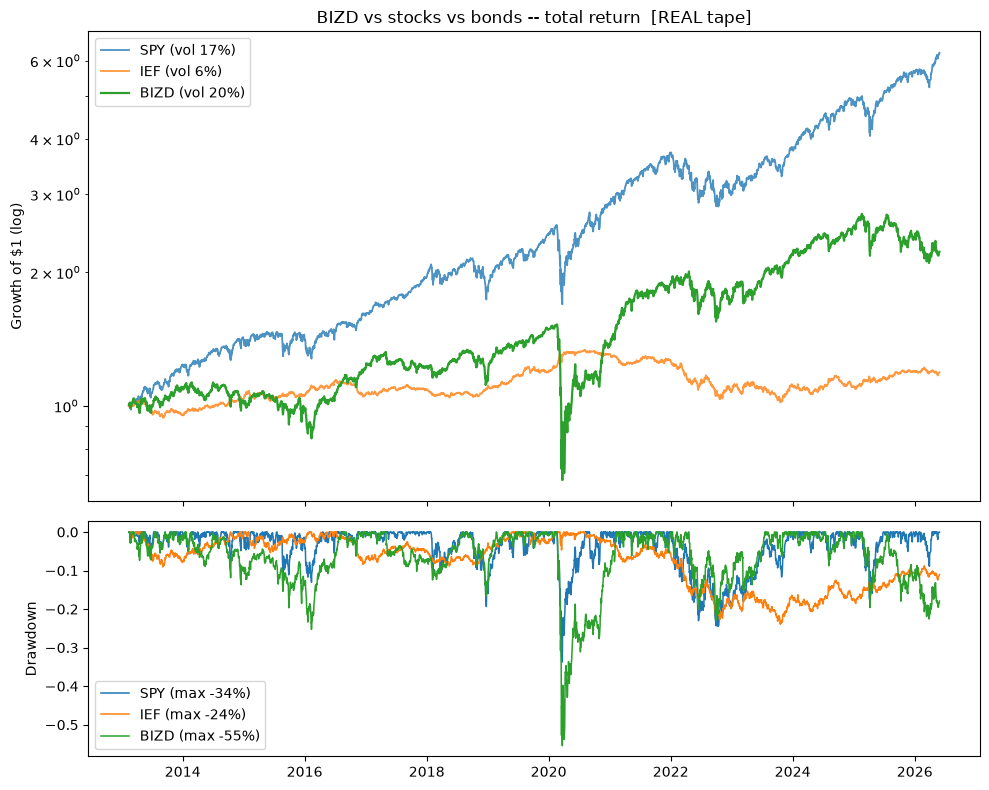

In [2]:
stats = {c: strategy.stats(rets[c]) for c in (BIZD, SPY, BND)}
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, height_ratios=[2, 1])
for c, style in [(SPY, dict(lw=1.3, alpha=.8)), (BND, dict(lw=1.3, alpha=.8)), (BIZD, dict(lw=1.6))]:
    ax1.plot(stats[c]['equity'], label=f"{c} (vol {stats[c]['vol']*100:.0f}%)", **style)
ax1.set_yscale('log'); ax1.set_ylabel('Growth of $1 (log)'); ax1.legend()
ax1.set_title(f'BIZD vs stocks vs bonds -- total return  [{TAPE} tape]')
for c in (SPY, BND, BIZD):
    eq = stats[c]['equity']; dd = eq/eq.cummax()-1
    ax2.plot(dd, label=f"{c} (max {dd.min()*100:.0f}%)", lw=1.1)
ax2.set_ylabel('Drawdown'); ax2.legend(); ax2.set_xlabel('')
plt.tight_layout(); plt.show()

The BIZD drawdown line plunges *below* the stock line in the COVID selloff. A real bond fund (the IEF line) barely moves. That's the whole story in one chart: BIZD's **risk** is shaped like a stock's — a *leveraged* stock's — not a bond's. And the total-return curve lands well below equities despite all that risk.

Now the yield illusion. The fund *quotes* ~10%; how much of that actually became wealth?

In [3]:
bizd_cagr = strategy.stats(rets[BIZD])['cagr']
hv = strategy.headline_vs_realised(bizd_cagr, QUOTED_YIELD)
print(f'[{TAPE}] quoted distribution yield  = {hv["quoted_yield"]*100:5.1f}%')
print(f'[{TAPE}] realised total-return CAGR = {hv["realised_cagr"]*100:5.2f}%')
print(f'[{TAPE}] phantom gap = {hv["gap"]*100:5.2f} pts  ({hv["fraction_phantom"]*100:.0f}% of the headline never became wealth)')

[REAL] quoted distribution yield  =  10.0%
[REAL] realised total-return CAGR =  6.21%
[REAL] phantom gap =  3.79 pts  (38% of the headline never became wealth)


On the real tape, of the **~10%** headline yield only **6.21%/yr** survived as total return — **38%** of it leaked away through fees on a leveraged book, NAV erosion, return of capital, and crash losses chewing through the carry. A distribution *rate* is not an earned *yield*.

Now the decisive test. Every time stocks fell more than 10%, here's what BIZD and bonds did over the *same* window:

In [4]:
eps = strategy.equity_drawdowns(rets[[SPY, BIZD, BND]], SPY, thresh=-0.10)
rows = [{'peak':e['peak'].date(),'trough':e['trough'].date(),
         f'{SPY} %':e['stock_loss']*100, f'{BIZD} %':e['others'][BIZD]*100, f'{BND} %':e['others'][BND]*100} for e in eps]
dd = pd.DataFrame(rows)
bizd_fell = (dd[f'{BIZD} %']<0).sum(); bnd_rose = (dd[f'{BND} %']>0).sum()
print(f'[{TAPE}] BIZD fell in {bizd_fell}/{len(dd)} equity crashes; bonds rose in {bnd_rose}/{len(dd)}')
dd.round(1)

[REAL] BIZD fell in 6/6 equity crashes; bonds rose in 4/6


,peak,trough,SPY %,BIZD %,IEF %
0,2015-07-20,2016-02-11,-13.000,-18.100,7.400
1,2018-01-26,2018-02-08,-10.100,-5.000,-1.200
2,2018-09-20,2018-12-24,-19.300,-15.400,3.400
3,2020-02-19,2020-03-23,-33.700,-55.000,6.400
4,2022-01-03,2022-10-12,-24.500,-15.800,-15.400
5,2025-02-19,2025-04-08,-18.800,-19.600,2.700


On the real tape BIZD fell in **6 of 6** equity crashes; bonds rose in **4**. The headline case is COVID: BIZD lost **-55.0%** — *far more than the S&P 500's -33.7%* — while Treasuries **gained +6.4%**. The '10% cushion' was a trapdoor.

## 5 · The verdict

- **Signal → Real.** BIZD moves with stocks, not bonds (beta to stocks +0.722, to bonds -0.241), and it fell in 6/6 crashes — the levered-equity risk is real, not a fluke.
- **Tradability → Mirage.** Only ~6.21% of the ~10% headline survived, for vol (20.1%) *above* equities and a worse drawdown (-55.4%) — a lower return than just owning the S&P. As a *safe high-yield* sleeve, it's a mirage.
- **Survives credit cycles? → Busted.** A high distribution rate on a leveraged private-credit book is not bond income. In a crash, BIZD is levered equity.

## 6 · Could you actually trade it?

You *can* buy BIZD in one click — it's liquid in normal times. The problem isn't friction, it's **what you're holding**: a basket of **externally-managed, balance-sheet-leveraged** funds whose underlying borrowers are private, non-investment-grade, often PE-owned mid-market companies — the exact credits that default in a downturn. You're paid a high distribution for that risk; you are not handed safety. If you want *income with safety*, a Treasury or IG-bond fund delivers the safety part for real.

## 7 · Going further 🚪

- Split BIZD's distribution into **net investment income vs return of capital**: how much of the ~10% is the fund handing back your own money?
- Compare BIZD (the *fund equity*) to **BKLN** ([Study 340](../../340-bank-loans/), the loans held directly): how much of the crash is the *second* layer of leverage?
- Compare to other 'is it what the brochure says?' income teardowns: preferreds ([Study 338](../../338-preferred-stocks/)), REITs ([Study 207](../../207-reits-diversifier/)).